In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows, feature_config_hash_text
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
# NEW: Import the unified training function
from src.models.train_balanced_bagging_ensemble import run_balanced_bagging

# CHANGED: Use sklearn metrics directly
import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from sklearn.model_selection import GroupShuffleSplit

paths = load_paths()
logger = setup_logger(level="INFO")

features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

logger.info("Loading VNAT features...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat"

vnat_old_path = paths.data_processed / "vnat" / "features_trainable.parquet"
if vnat_old_path.exists():
    vnat_old = pd.read_parquet(vnat_old_path)
    split_map = dict(zip(vnat_old["capture_id"], vnat_old["split"]))
    vnat_feats["split"] = vnat_feats["capture_id"].map(split_map).fillna("unknown")
else:
    logger.warning(f"Old features file not found: {vnat_old_path}. Setting splits to 'unknown'.")
    vnat_feats["split"] = "unknown"

if (vnat_feats["split"] != "unknown").any():
    vnat_feats = vnat_feats[vnat_feats["split"] != "unknown"].copy()

if "q_min_packets_ok" in vnat_feats.columns:
    vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()

logger.info("Loading ISCX features...")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

iscx_old_path = paths.data_processed / "iscx" / "features.parquet"
if iscx_old_path.exists():
    iscx_old = pd.read_parquet(iscx_old_path)
    split_map_iscx = dict(zip(iscx_old["capture_id"], iscx_old["split"]))
    iscx_feats["split"] = iscx_feats["capture_id"].map(split_map_iscx).fillna("unknown")
else:
    logger.warning(f"Old features file not found: {iscx_old_path}. Setting splits to 'unknown'.")
    iscx_feats["split"] = "unknown"

if (iscx_feats["split"] != "unknown").any():
    iscx_feats = iscx_feats[iscx_feats["split"] != "unknown"].copy()

if "q_min_packets_ok" in iscx_feats.columns:
    iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()

df_all = pd.concat([vnat_feats, iscx_feats], ignore_index=True)
df_all["split"] = df_all["split"].replace({"iscx_train": "train", "iscx_val": "val", "iscx_test": "test"})

# Rebalance VNAT
logger.info("Rebalancing VNAT splits...")
vnat_mask = df_all["dataset"] == "vnat"
vnat_df = df_all[vnat_mask].copy()
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss.split(vnat_df, groups=vnat_df["capture_id"]))
vnat_train = vnat_df.iloc[train_idx].copy()
vnat_temp = vnat_df.iloc[temp_idx].copy()

gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val_test.split(vnat_temp, groups=vnat_temp["capture_id"]))
vnat_val = vnat_temp.iloc[val_idx].copy()
vnat_test = vnat_temp.iloc[test_idx].copy()

vnat_train["split"] = "train"
vnat_val["split"] = "val"
vnat_test["split"] = "test"

vnat_balanced = pd.concat([vnat_train, vnat_val, vnat_test], ignore_index=True)
df_all = pd.concat([df_all[~vnat_mask], vnat_balanced], ignore_index=True)

# Voipbuster Override
vb_train_cap = "vpn_vpn_voipbuster1a.pcap"
vb_test_cap = "vpn_vpn_voipbuster1b.pcap"
df_all.loc[df_all["capture_id"] == vb_train_cap, "split"] = "train"
df_all.loc[df_all["capture_id"] == vb_test_cap, "split"] = "test"

print("Splits:", df_all["split"].value_counts())

# --- Compute Dataset-Balanced Sample Weights ---
logger.info("Computing Dataset-Balanced Sample Weights...")
train_mask = df_all["split"] == "train"
df_train = df_all[train_mask]

counts = df_train["dataset"].value_counts()
n_vnat = counts.get("vnat", 0)
n_iscx = counts.get("iscx", 0)
n_total = len(df_train)

w_vnat = n_total / (2 * n_vnat) if n_vnat > 0 else 0
w_iscx = n_total / (2 * n_iscx) if n_iscx > 0 else 0

df_all["sample_weight"] = 1.0
df_all.loc[train_mask & (df_all["dataset"] == "vnat"), "sample_weight"] = w_vnat
df_all.loc[train_mask & (df_all["dataset"] == "iscx"), "sample_weight"] = w_iscx
print(f"Weights: VNAT={w_vnat:.4f}, ISCX={w_iscx:.4f}")


2026-03-05 18:17:03 | INFO | ai-vpn-firewall | Loading VNAT features...
2026-03-05 18:17:59 | WARNING | ai-vpn-firewall | Old features file not found: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\vnat\features_trainable.parquet. Setting splits to 'unknown'.
2026-03-05 18:17:59 | INFO | ai-vpn-firewall | Loading ISCX features...
2026-03-05 18:19:46 | INFO | ai-vpn-firewall | Rebalancing VNAT splits...
Splits: split
train    14260
val       3217
test      2431
Name: count, dtype: int64
2026-03-05 18:19:47 | INFO | ai-vpn-firewall | Computing Dataset-Balanced Sample Weights...
Weights: VNAT=1.2264, ISCX=0.8442


In [2]:
logger.info("Fitting FeaturePipeline...")
pipeline = FeaturePipeline().fit(df_all[df_all["split"] == "train"])
feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline.save(feature_art, feature_config_hash=feature_config_hash_text(features_yaml))

logger.info("Transforming features for training...")
df_transformed = pipeline.transform(df_all)
# Add back metadata
meta_cols = ["label", "split", "capture_id", "dataset", "flow_id"]
for col in meta_cols:
    df_transformed[col] = df_all[col].values


2026-03-05 18:19:47 | INFO | ai-vpn-firewall | Fitting FeaturePipeline...
2026-03-05 18:19:48 | INFO | ai-vpn-firewall | Transforming features for training...


In [3]:
logger.info("Training CatBoost (Balanced Bagging)...")
# Use the new unified training function, but restrict to 'cat'
results = run_balanced_bagging(
    df=df_transformed,
    label_col="label",
    group_col="capture_id",
    dataset_col="dataset",
    split_col="split",
    bags_per_family=3,
    majority_ratio=1.0,
    target_fprs="0.001,0.005,0.01",
    seed=42,
    output_dir=str(paths.artifacts_dir / "balanced_bagging_cat"),
    model_types=["cat"] # Only train CatBoost
)


2026-03-05 18:19:49 | INFO | ai-vpn-firewall | Training CatBoost (Balanced Bagging)...


In [4]:
print("\n" + "="*60)
print("CATBOOST EVALUATION (BALANCED BAGGING)")
print("="*60)

# Helper to print metrics
def print_metrics(name, metrics_dict):
    print(f"\n--- {name} ---")
    if "auc" in metrics_dict and metrics_dict["auc"] is not None:
        print(f"ROC AUC: {metrics_dict['auc']:.4f}")
    if "pr_auc" in metrics_dict and metrics_dict["pr_auc"] is not None:
        print(f"PR AUC:  {metrics_dict['pr_auc']:.4f}")

    for key, val in metrics_dict.items():
        if key.startswith("fpr_"):
            print(f"\nPolicy: {key}")
            print(f"  Threshold: {val['threshold']:.4f}")
            print(f"  Recall:    {val['recall']:.4f}")
            print(f"  Precision: {val['precision']:.4f}")
            print(f"  FPR:       {val['fpr']:.5f}")
            cm = val['confusion']
            print(f"  Confusion: TN={cm['tn']}, FP={cm['fp']}, FN={cm['fn']}, TP={cm['tp']}")

if "val" in results:
    print_metrics("VALIDATION SET", results["val"])

if "test_overall" in results:
    print_metrics("TEST SET (OVERALL)", results["test_overall"])

for key in results:
    if key.startswith("test_") and key != "test_overall":
        print_metrics(f"TEST SET ({key.replace('test_', '').upper()})", results[key])

print("\n" + "="*60)



CATBOOST EVALUATION (BALANCED BAGGING)

--- VALIDATION SET ---
ROC AUC: 0.9919
PR AUC:  0.9802

Policy: fpr_0.001
  Threshold: 0.9887
  Recall:    0.8204
  Precision: 0.9951
  FPR:       0.00121
  Confusion: TN=2468, FP=3, FN=134, TP=612

Policy: fpr_0.005
  Threshold: 0.9546
  Recall:    0.8861
  Precision: 0.9807
  FPR:       0.00526
  Confusion: TN=2458, FP=13, FN=85, TP=661

Policy: fpr_0.01
  Threshold: 0.8989
  Recall:    0.8995
  Precision: 0.9641
  FPR:       0.01012
  Confusion: TN=2446, FP=25, FN=75, TP=671

--- TEST SET (OVERALL) ---
ROC AUC: 0.9839
PR AUC:  0.9292

Policy: fpr_0.001
  Threshold: 0.9887
  Recall:    0.4106
  Precision: 0.9902
  FPR:       0.00046
  Confusion: TN=2184, FP=1, FN=145, TP=101

Policy: fpr_0.005
  Threshold: 0.9546
  Recall:    0.5122
  Precision: 0.9767
  FPR:       0.00137
  Confusion: TN=2182, FP=3, FN=120, TP=126

Policy: fpr_0.01
  Threshold: 0.8989
  Recall:    0.6504
  Precision: 0.9816
  FPR:       0.00137
  Confusion: TN=2182, FP=3, FN=


--- Generating Plots for CatBoost ---


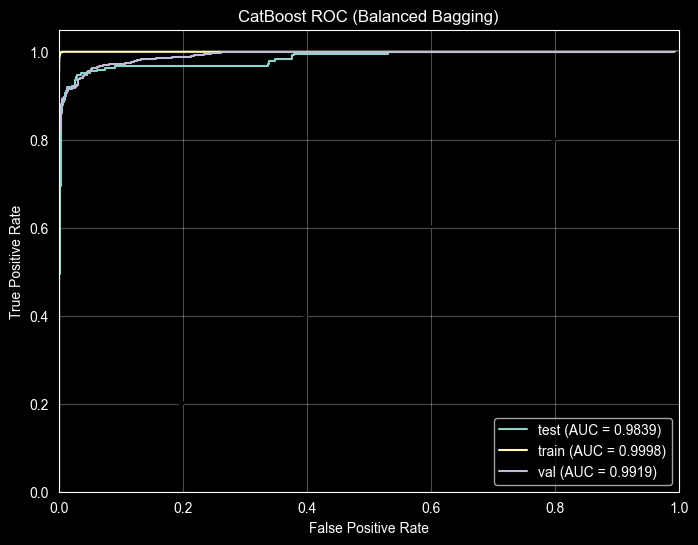

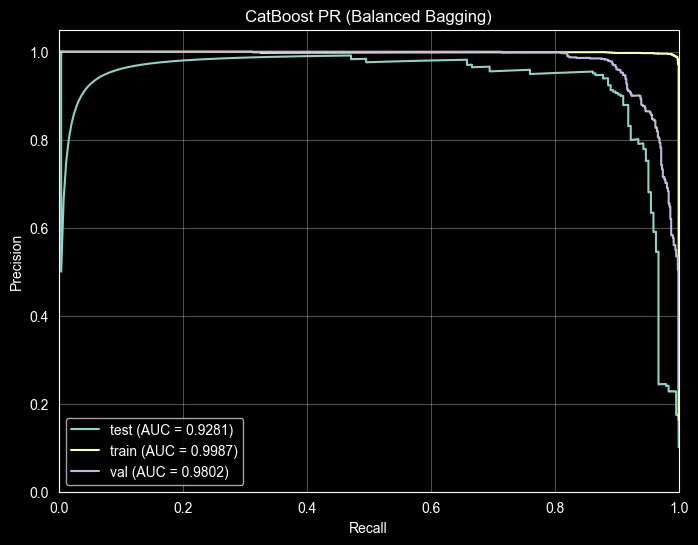

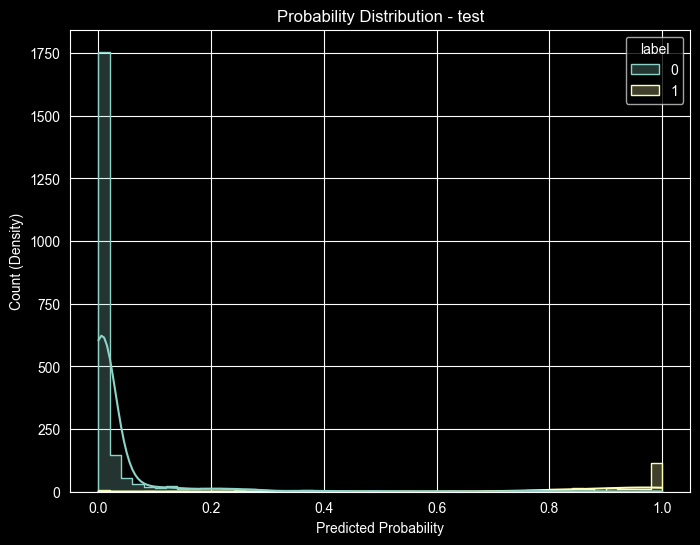

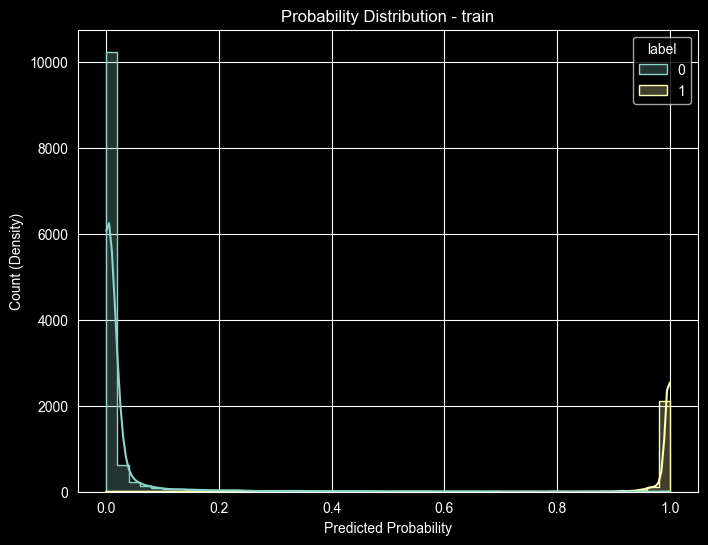

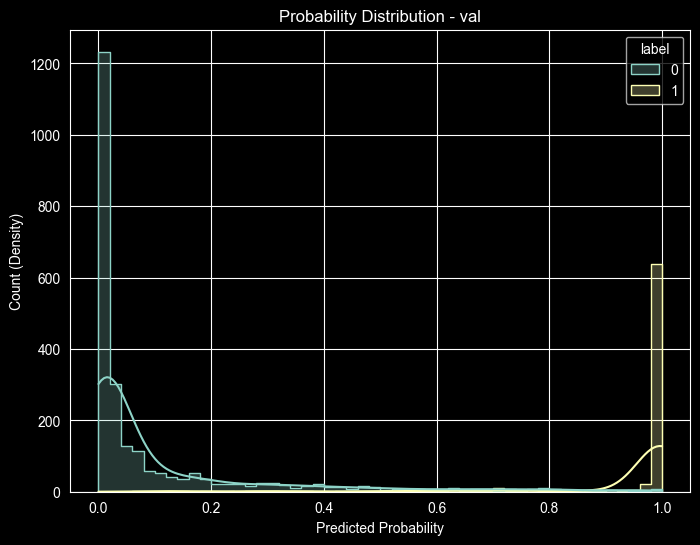


--- Confusion Matrices at Policy Thresholds (Test Set) ---


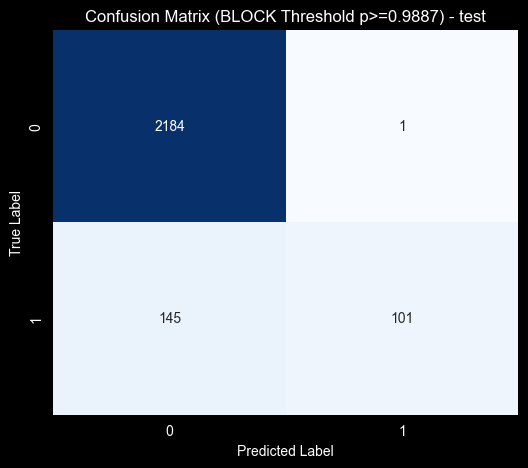

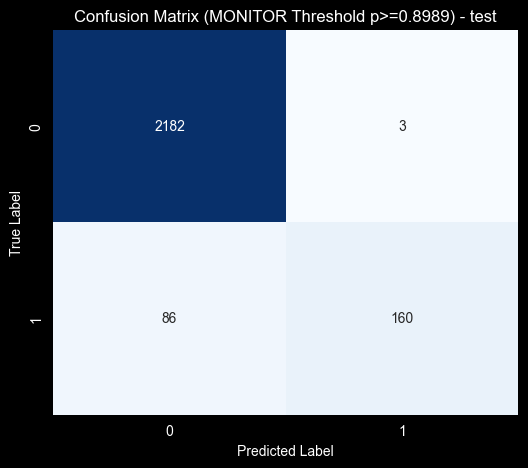

In [5]:
# 3. Visualization
# Load the full predictions CSV (which now contains train/val/test)
preds_path = paths.artifacts_dir / "balanced_bagging_cat" / "predictions.csv"
if preds_path.exists():
    df_preds = pd.read_csv(preds_path)
    df_preds = df_preds.rename(columns={"prob": "p_calib"})

    print("\n--- Generating Plots for CatBoost ---")
    plot_roc_curves(df_preds, prob_col="p_calib", title="CatBoost ROC (Balanced Bagging)")
    plot_pr_curves(df_preds, prob_col="p_calib", title="CatBoost PR (Balanced Bagging)")
    plot_probability_distributions(df_preds, prob_col="p_calib")

    # Get thresholds from results
    val_metrics = results.get("val", {})
    def get_thr(metrics_dict, fpr):
        key = f"fpr_{fpr}"
        if key in metrics_dict: return metrics_dict[key]["threshold"]
        return 0.99

    T_BLOCK = get_thr(val_metrics, 0.001)
    T_MONITOR = get_thr(val_metrics, 0.01)

    # NEW: Confusion Matrices for BLOCK and MONITOR thresholds (Test set only for clarity)
    print("\n--- Confusion Matrices at Policy Thresholds (Test Set) ---")
    test_preds = df_preds[df_preds["split"] == "test"]
    plot_confusion_matrices(test_preds, prob_col="p_calib", threshold=T_BLOCK, title=f"Confusion Matrix (BLOCK Threshold p>={T_BLOCK:.4f})")
    plot_confusion_matrices(test_preds, prob_col="p_calib", threshold=T_MONITOR, title=f"Confusion Matrix (MONITOR Threshold p>={T_MONITOR:.4f})")
else:
    print("Predictions file not found, skipping plots.")
